In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import GridSearchCV
import shap
from sklearn.metrics import roc_curve, roc_auc_score
from PyALE import ale


In [3]:
from xgboost import XGBClassifier

In [4]:
from sklearn.metrics import (f1_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score
)

In [5]:
#Load data
df = pd.read_csv("../data/mental_health_data.csv")
df.head()

,Name,Age,Marital_Status,Education_Level,Number_of_Children,Smoking_Status,Physical_Activity_Level,Employment_Status,Income,Alcohol_Consumption,Dietary_Habits,Sleep_Patterns,History_of_Mental_Illness,History_of_Substance_Abuse,Family_History_of_Depression,Chronic_Medical_Conditions,Record_ID,data_split
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes,100000,validation
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes,100001,validation
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No,100002,validation
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No,100003,validation
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes,100004,validation


From the EDA, we had a general understanding  of the data, including the distribution of features, the relationship between features and the target variable. In this scripts, I'll start testing the model and some hypeterparameter tuning. 

## Transformation

#### Categorical features

In [6]:
exl_cols = ["Name", "Record_ID", "data_split", "History_of_Mental_Illness"]

In [7]:
df["Number_of_Children"] = df["Number_of_Children"].replace(4, 3)

I would not group widowed and divorced together in this case. Normally, considering the different use cases and how the results will be used, I would apply some consideration to treating vulnerable customers. If the results could result in treating customers unfairly, then I would group vulnerable customers into another set. However, in this specific situation, I will not take any action, as there is an important link between marital status and the likelihood of depression.

I will treat PHD as a distinct education level, as merging it with Master's would remove information from the model. If education is associated with differences in the target, combining PhD with Master's could hide that difference.

In [8]:
train = df[df["data_split"] == "train"].copy()
validation = df[df["data_split"] == "validation"].copy()
test = df[df["data_split"] == "test"].copy()

X_train = train.drop(columns=exl_cols)
X_val = validation.drop(columns=exl_cols)
X_test = test.drop(columns=exl_cols)


In [9]:
y_train = train["History_of_Mental_Illness"]
y_val = validation["History_of_Mental_Illness"]
y_test = test["History_of_Mental_Illness"]

In [10]:
numeric_features = ["Age", "Income"]
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()
categorical_features.append("Number_of_Children")
categorical_features

['Marital_Status',
 'Education_Level',
 'Smoking_Status',
 'Physical_Activity_Level',
 'Employment_Status',
 'Alcohol_Consumption',
 'Dietary_Habits',
 'Sleep_Patterns',
 'History_of_Substance_Abuse',
 'Family_History_of_Depression',
 'Chronic_Medical_Conditions',
 'Number_of_Children']

In [11]:
#Frequent encoding for categorical features
marital_frequency = (X_train["Marital_Status"].value_counts(normalize=True))
X_train["Marital_Status"] = (X_train["Marital_Status"].map(marital_frequency).fillna(0))
X_val["Marital_Status"] = (X_val["Marital_Status"].map(marital_frequency).fillna(0))
X_test["Marital_Status"] = (X_test["Marital_Status"].map(marital_frequency).fillna(0))

In [12]:
#Orindial encoding 
ordinal_features = ["Education_Level", "Physical_Activity_Level", "Sleep_Patterns","Alcohol_Consumption","Dietary_Habits", "Number_of_Children", "Smoking_Status"]

In [13]:
ordinal_categories = [
    [   "High School",
        "Associate Degree",
        "Bachelor's Degree",
        "Master's Degree",
        "PhD"
    ],

    [   "Sedentary",
        "Moderate",
        "Active"
    ],

    [   "Poor",
        "Fair",
        "Good"
    ],

    [   "Low",
        "Moderate",
        "High"
    ],

    [
        "Unhealthy",
        "Moderate",
        "Healthy"
    ],

    [
        "0",
        "1",
        "2",
        "3"
    ],

    [
        "Non-Smoker",
        "Former",
        "Current"
    ]
]

In [14]:
ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

In [15]:
# Convert True/False to 0/1
binary_features = [
    "Employment_Status",
    "History_of_Substance_Abuse",
    "Family_History_of_Depression",
    "Chronic_Medical_Conditions"
]

binary_mappings = {
    "Yes": 1,
    "No": 0,
    "Employed": 1,
    "Unemployed": 0
}

for feature in binary_features:
    X_train[feature] = X_train[feature].map(binary_mappings)
    X_val[feature] = X_val[feature].map(binary_mappings)
    X_test[feature] = X_test[feature].map(binary_mappings)

# Employment status
for data in [X_train, X_val, X_test]:
    data["Employment_Status"] = data["Employment_Status"].map({
        "Employed": 1,
        "Unemployed": 0
    })

#### Numerical Feataures 

In [16]:
#Numeric imputer
numeric_features

['Age', 'Income']

From EDA, we noticed that Income is a right-skewed feature, so normally we could take some mathmatical transformation to it, like Log(x) to reduce the effect of the long right tail.  However, using the original Income values makes the model output much easier explain to stakeholders than log(x).Particularly when using a more complex model such as XGBoost. Therefore, I'd like retain Income in its original scale and apply a cap to limit the influence of extreme values.

In [17]:
df["Income"] = df["Income"].clip(upper=150000)
X_train["Income"] = X_train["Income"].clip(upper=150000)
X_val["Income"] = X_val["Income"].clip(upper=150000)
X_test["Income"] = X_test["Income"].clip(upper=150000)

In [18]:
new_num_features = [
    "Age",
    "Income",
    "Marital_Status",
    "Employment_Status",
    "History_of_Substance_Abuse",
    "Family_History_of_Depression",
    "Chronic_Medical_Conditions"
]

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", ordinal_encoder, ordinal_features),
        ("numeric", "passthrough", new_num_features),
    ]
)

In [20]:
X_train_transformed = preprocessor.fit_transform(X_train)

In [21]:
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

## Train model

In [22]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_val = y_val.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [23]:
## Train a default XGboost Model 
xgb_model = XGBClassifier(
    objective = "binary:logistic",
    booster='gbtree',
    reg_alpha=1,
    reg_lambda=0,
    gamma=0,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=1,
    subsample=1,
    n_estimators=100,
    n_jobs=1,
    eval_metric="auc",
    early_stopping_rounds=50,
    enable_categorical=True
)

xgb_model.fit(
    X_train_transformed,
    y_train,    
    eval_set=[(X_val_transformed, y_val)],
)

[0]	validation_0-auc:0.59782
[1]	validation_0-auc:0.59781
[2]	validation_0-auc:0.59819
[3]	validation_0-auc:0.59820
[4]	validation_0-auc:0.59828
[5]	validation_0-auc:0.59831
[6]	validation_0-auc:0.59832
[7]	validation_0-auc:0.59837
[8]	validation_0-auc:0.59838
[9]	validation_0-auc:0.59837
[10]	validation_0-auc:0.59837
[11]	validation_0-auc:0.59841
[12]	validation_0-auc:0.59847
[13]	validation_0-auc:0.59845
[14]	validation_0-auc:0.59835
[15]	validation_0-auc:0.59838
[16]	validation_0-auc:0.59817
[17]	validation_0-auc:0.59816
[18]	validation_0-auc:0.59822
[19]	validation_0-auc:0.59808
[20]	validation_0-auc:0.59807
[21]	validation_0-auc:0.59804
[22]	validation_0-auc:0.59808
[23]	validation_0-auc:0.59799
[24]	validation_0-auc:0.59801
[25]	validation_0-auc:0.59803
[26]	validation_0-auc:0.59802
[27]	validation_0-auc:0.59801
[28]	validation_0-auc:0.59802
[29]	validation_0-auc:0.59799
[30]	validation_0-auc:0.59802
[31]	validation_0-auc:0.59803
[32]	validation_0-auc:0.59803
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,'auc'


In [24]:
print(xgb_model.n_estimators)
print(xgb_model.best_iteration)
print(xgb_model.best_score)

100
12
0.5984696164523732


In [25]:
#Gain importance
feature_list = preprocessor.get_feature_names_out()
booster = xgb_model.get_booster()
gain_importance = booster.get_score(importance_type="gain")
gain_values = [
    gain_importance.get(f"f{i}", 0)
    for i in range(len(feature_list))
]

In [26]:
#SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val_transformed)
shap_importance = np.abs(shap_values).mean(axis=0)

In [27]:
perm_result = permutation_importance(
    xgb_model,
    X_val_transformed,
    y_val,
    scoring="roc_auc"
)

permutation_values = perm_result.importances_mean

In [28]:
feature_importance = pd.DataFrame({
    "Feature": feature_list,
    "Gain": gain_values,
    "SHAP": shap_importance,
    "Permutation": permutation_values
})

feature_importance["Gain_Rank"] = feature_importance["Gain"].rank(ascending=False)
feature_importance["SHAP_Rank"] = feature_importance["SHAP"].rank(ascending=False)
feature_importance["Permutation_Rank"] = feature_importance["Permutation"].rank(ascending=False)

feature_importance["Overall_Rank"] = (
    feature_importance[
        ["Gain_Rank", "SHAP_Rank", "Permutation_Rank"]
    ].mean(axis=1)
)

feature_importance = feature_importance.sort_values("Overall_Rank", ascending=True)
feature_importance

,Feature,Gain,SHAP,Permutation,Gain_Rank,SHAP_Rank,Permutation_Rank,Overall_Rank
8,numeric__Income,149.581253,0.096367,0.091615,1.0,1.0,1.0,1.000000
0,ordinal__Education_Level,59.977940,0.018247,0.021949,3.0,2.0,2.0,2.333333
6,ordinal__Smoking_Status,81.867981,0.011438,0.011998,2.0,3.0,3.0,2.666667
7,numeric__Age,3.524517,0.002615,0.000151,7.0,4.0,6.0,5.666667
9,numeric__Marital_Status,3.485536,0.000971,0.000222,8.0,6.0,4.0,6.000000
3,ordinal__Alcohol_Consumption,4.223040,0.000206,0.000182,4.0,10.0,5.0,6.333333
2,ordinal__Sleep_Patterns,3.616696,0.001531,-0.000040,6.0,5.0,13.0,8.000000
5,ordinal__Number_of_Children,2.617449,0.000649,0.000127,11.0,7.0,7.0,8.333333
12,numeric__Family_History_of_Depression,3.777727,0.000168,-0.000004,5.0,11.0,11.0,9.000000
1,ordinal__Physical_Activity_Level,2.846459,0.000444,0.000091,10.0,9.0,8.0,9.000000


I started with adding reg_alpha in XGBoost as an initial feature screening step. The idea was to reduce model complexity and see which variables the model was actually using in its tree splits. This gave me a quick first pass understanding of which features appeared less useful, which was practical when work on large dataset. I then validated the feature selection using model performance and used SHAP and permutation importance to get a more robust understanding of feature importance.
Given a short timeframe, I decided to drop bottom 7 features based on this inital feature results.

### Reduced model

In [23]:
reduced_ordinal_features = [
    "Education_Level",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Dietary_Habits",
    "Physical_Activity_Level",
    "Number_of_Children"
]

reduced_num_features = [
    "Age",
    "Income",
    "Marital_Status",
    # "Family_History_of_Depression",
]

reduced_ordinal_encoder = OrdinalEncoder(
    categories=[
    [   "High School",
        "Associate Degree",
        "Bachelor's Degree",
        "Master's Degree",
        "PhD"
    ],

    [
        "Non-Smoker",
        "Former",
        "Current"
    ],
    
    [   "Low",
        "Moderate",
        "High"
    ],

    [
        "Unhealthy",
        "Moderate",
        "Healthy"
    ],

    [
        "Sedentary",
        "Moderate",
        "Active"
    ],

    [
        "0",
        "1",
        "2",
        "3"
    ]
    ],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

In [24]:
reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", reduced_ordinal_encoder, reduced_ordinal_features),
        ("numeric", "passthrough", reduced_num_features)
    ]
)

In [25]:
X_train_reduced = reduced_preprocessor.fit_transform(X_train)
X_val_reduced = reduced_preprocessor.transform(X_val)
X_test_reduced = reduced_preprocessor.transform(X_test)

In [32]:
xgb_reduced = XGBClassifier(
    objective = "binary:logistic",
    booster='gbtree',
    reg_alpha=1,
    reg_lambda=0,
    gamma=0,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=1,
    subsample=1,
    n_estimators=100,
    n_jobs=1,
    eval_metric="auc",
    early_stopping_rounds=50,
    enable_categorical=True
)

xgb_reduced.fit(
    X_train_reduced,
    y_train,
    eval_set=[(X_val_reduced, y_val)],
)

[0]	validation_0-auc:0.59760
[1]	validation_0-auc:0.59768
[2]	validation_0-auc:0.59802
[3]	validation_0-auc:0.59823
[4]	validation_0-auc:0.59839
[5]	validation_0-auc:0.59829
[6]	validation_0-auc:0.59839
[7]	validation_0-auc:0.59843
[8]	validation_0-auc:0.59847
[9]	validation_0-auc:0.59851
[10]	validation_0-auc:0.59835
[11]	validation_0-auc:0.59856
[12]	validation_0-auc:0.59843
[13]	validation_0-auc:0.59851
[14]	validation_0-auc:0.59846
[15]	validation_0-auc:0.59844
[16]	validation_0-auc:0.59817
[17]	validation_0-auc:0.59818
[18]	validation_0-auc:0.59819
[19]	validation_0-auc:0.59813
[20]	validation_0-auc:0.59810
[21]	validation_0-auc:0.59809
[22]	validation_0-auc:0.59807
[23]	validation_0-auc:0.59805
[24]	validation_0-auc:0.59803
[25]	validation_0-auc:0.59802
[26]	validation_0-auc:0.59804
[27]	validation_0-auc:0.59808
[28]	validation_0-auc:0.59806
[29]	validation_0-auc:0.59803
[30]	validation_0-auc:0.59801
[31]	validation_0-auc:0.59797
[32]	validation_0-auc:0.59794
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,'auc'


In [33]:
print(xgb_reduced.n_estimators)
print(xgb_reduced.best_iteration)
print(xgb_reduced.best_score)

100
11
0.5985553104510308


### Compare the Results through Metrics

In [34]:
y_pred_full = xgb_model.predict(X_val_transformed)
y_prob_full = xgb_model.predict_proba(X_val_transformed)[:, 1]

y_pred_reduced = xgb_reduced.predict(X_val_reduced)
y_prob_reduced = xgb_reduced.predict_proba(X_val_reduced)[:, 1]

In [37]:
comparison = pd.DataFrame({
    "Model": ["XGBoost_14features","XGBoost_9features"],
    "F1": [f1_score(y_val, y_pred_full), f1_score(y_val, y_pred_reduced)],
    "AUROC": [roc_auc_score(y_val, y_prob_full), roc_auc_score(y_val, y_prob_reduced)],
    "AUPRC": [average_precision_score(y_val, y_prob_full), average_precision_score(y_val, y_prob_reduced)],
    "Accuracy":[accuracy_score(y_val, y_pred_full), accuracy_score(y_val, y_pred_reduced)]
})
comparison

,Model,F1,AUROC,AUPRC,Accuracy
0,XGBoost_14features,0.0,0.598470,0.365522,0.69849
1,XGBoost_9features,0.0,0.598555,0.365447,0.69849


### Compare the Results through Bin groups

In [44]:
models = {
    "XGBoost_14features": {"model": xgb_model, "X_train": X_train_transformed,},
    "XGBoost_9features": {"model": xgb_reduced, "X_train": X_train_reduced}
}

train_results_df = pd.DataFrame({"pred_group": range(10)})

#Cut bins

all_results = []

for model_name, data in models.items():

    model = data["model"]
    y_prob_train = model.predict_proba(data["X_train"])[:, 1]

    _, train_bins = pd.qcut(
        y_prob_train,
        q=11,
        retbins=True,
        duplicates="drop"
    )

    train_groups = pd.cut(
        y_prob_train,
        bins=train_bins,
        labels=False,
        include_lowest=True
    )
    
    temp_df = pd.DataFrame({
        "pred_group": train_groups,
        "actual": y_train.values,
        "predict": y_prob_train
    })
    
    summary = (
        temp_df
        .groupby("pred_group")
        .agg(
            actual=("actual", "mean"),
            predict=("predict", "mean")
        )
    )

    summary = summary.rename(columns={
        "actual": f"{model_name}_actual",
        "predict": f"{model_name}_predict"
    })

    train_results_df = train_results_df.merge(
        summary,
        on="pred_group",
        how="left"
    )

    train_results_df

In [45]:
train_results_df

,pred_group,XGBoost_14features_actual,XGBoost_14features_predict,XGBoost_9features_actual,XGBoost_9features_predict
0,0,0.200442,0.271370,0.200442,0.273544
1,1,0.217276,0.273006,0.217276,0.275043
2,2,0.267237,0.296082,0.270221,0.296830
3,3,0.296662,0.302651,0.296788,0.303325
4,4,0.304681,0.305197,0.304616,0.304961
5,5,0.323810,0.310446,0.324330,0.310468
6,6,0.373309,0.326099,0.377277,0.325770
7,7,0.397785,0.335703,0.394538,0.333857
8,8,0.403296,0.337177,0.404386,0.335090
9,9,0.409526,0.338649,0.409203,0.336519


In [46]:
models = {
    "XGBoost_14features": {"model": xgb_model, "X_val": X_val_transformed},
    "XGBoost_9features": {"model": xgb_reduced, "X_val": X_val_reduced}
}

val_results_df = pd.DataFrame({"pred_group": range(10)})

#Cut bins

all_results = []

for model_name, data in models.items():

    model = data["model"]
    y_prob_val = model.predict_proba(data["X_val"])[:, 1]

    _, val_bins = pd.qcut(
        y_prob_val,
        q=11,
        retbins=True,
        duplicates="drop"
    )

    val_groups = pd.cut(
        y_prob_val,
        bins=val_bins,
        labels=False,
        include_lowest=True
    )
    temp_df = pd.DataFrame({
        "pred_group": val_groups,
        "actual": y_val.values,
        "predict": y_prob_val
    })
    
    summary = (
        temp_df
        .groupby("pred_group")
        .agg(
            actual=("actual", "mean"),
            predict=("predict", "mean")
        )
    )

    summary = summary.rename(columns={
        "actual": f"{model_name}_actual",
        "predict": f"{model_name}_predict"
    })

    val_results_df = val_results_df.merge(
        summary,
        on="pred_group",
        how="left"
    )
    val_results_df

In [47]:
val_results_df


,pred_group,XGBoost_14features_actual,XGBoost_14features_predict,XGBoost_9features_actual,XGBoost_9features_predict
0,0,0.199616,0.271373,0.199616,0.273548
1,1,0.197861,0.272760,0.197861,0.274564
2,2,0.281736,0.295192,0.285306,0.295987
3,3,0.304880,0.302652,0.296109,0.303323
4,4,0.293145,0.305179,0.296807,0.304914
5,5,0.304518,0.310406,0.304473,0.310363
6,6,0.371548,0.326181,0.377379,0.325807
7,7,0.396177,0.335706,0.395365,0.333860
8,8,0.391068,0.337179,0.389626,0.335090
9,9,0.396819,0.338631,0.397568,0.336520


Both models have an F1 score of 0 because all predictions are below the 50% threshold, so the model predicts every case as 0. 

Initially modelled the full feature set and then reduced it based on feature importance. The reduced model achieved comparable validation performance, so I retained the simpler feature set. From model evaluation results both models show signs of underfitting.


### Simple HPT and Feature Selection

Because GridSearch was taking quite a long time to run on my personal laptop, and I had a limited amount of time for the project, I decided to tune the XGBoost model manually instead.

I started by testing different settings such as `max_depth`, `learning rate`, `no estimators`, and `minchild weight`. Some of the early models were overfitting, where the training AUC(around 0.62..) was much higher than the validation AUC(around 0.59..).

To reduce overfitting, I gradually added more regularisation and adjusted parameters such as `gamma`, `reg_alpha`, `reg_lambda`, `subsample`, and `colsample_bytree`. I also used early stopping to stop training when the validation AUC stopped improving.

I tested several combinations and compared the validation AUC after each change. The results were generally around 0.60 AUROC, so increasing the model complexity did not lead to a meaningful improvement. This suggests that the available features may have limited.

I think there is still room to improve the model with more hyperparameter tuning, such as GridSearch or Bayesian optimisation. If I had more time and computing resources, I would explore more parameters.

I would also look at the features again, and feature correlation. I could test removing some lower-importance features to see if a simpler model performs better, as well as adding some of the removed features back to see whether they provide any useful information. This would help me understand whether the current performance is mainly limited by the model settings or by the available features.


In [26]:
xgb_hpt = XGBClassifier(
    objective="binary:logistic",
    booster="gbtree",
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=20,
    subsample=1,
    colsample_bytree=0.5,
    colsample_bylevel=1,
    gamma=10,
    reg_alpha=1,
    reg_lambda=10,
    n_estimators=1000,
    eval_metric="auc",
    early_stopping_rounds=50,
)

xgb_hpt.fit(
    X_train_reduced,
    y_train,
    eval_set=[
        (X_train_reduced, y_train),
        (X_val_reduced, y_val)
    ],
    verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'auc'


In [27]:
print(xgb_hpt.n_estimators)
print(xgb_hpt.best_iteration)
print(xgb_hpt.best_score)

1000
272
0.5995500007154108


In [28]:
models = {
    "XGBoost_9features": {"model": xgb_hpt, "X_train": X_train_reduced}
}

train_results_df = pd.DataFrame({"pred_group": range(10)})

#Cut bins

all_results = []

for model_name, data in models.items():

    model = data["model"]
    y_prob_train = model.predict_proba(data["X_train"])[:, 1]

    _, train_bins = pd.qcut(
        y_prob_train,
        q=10,
        retbins=True,
        duplicates="drop"
    )

    train_groups = pd.cut(
        y_prob_train,
        bins=train_bins,
        labels=False,
        include_lowest=True
    )
    
    temp_df = pd.DataFrame({
        "pred_group": train_groups,
        "actual": y_train.values,
        "predict": y_prob_train
    })
    
    summary = (
        temp_df
        .groupby("pred_group")
        .agg(
            actual=("actual", "mean"),
            predict=("predict", "mean")
        )
    )

    summary = summary.rename(columns={
        "actual": f"{model_name}_actual",
        "predict": f"{model_name}_predict"
    })

    train_results_df = train_results_df.merge(
        summary,
        on="pred_group",
        how="left"
    )

    train_results_df

In [29]:
train_results_df

,pred_group,XGBoost_9features_actual,XGBoost_9features_predict
0,0,0.199259,0.229018
1,1,0.201469,0.234590
2,2,0.219360,0.247398
3,3,0.297116,0.289596
4,4,0.303478,0.305626
5,5,0.303863,0.310555
6,6,0.332346,0.337213
7,7,0.399478,0.357046
8,8,0.399726,0.368693
9,9,0.401695,0.377594


In [30]:
models = {
    "XGBoost_9features": {"model": xgb_hpt, "X_val": X_val_reduced}
}

val_results_df = pd.DataFrame({"pred_group": range(10)})

#Cut bins

all_results = []

for model_name, data in models.items():

    model = data["model"]
    y_prob_val = model.predict_proba(data["X_val"])[:, 1]

    _, val_bins = pd.qcut(
        y_prob_val,
        q=10,
        retbins=True,
        duplicates="drop"
    )

    val_groups = pd.cut(
        y_prob_val,
        bins=val_bins,
        labels=False,
        include_lowest=True
    )
    temp_df = pd.DataFrame({
        "pred_group": val_groups,
        "actual": y_val.values,
        "predict": y_prob_val
    })
    
    summary = (
        temp_df
        .groupby("pred_group")
        .agg(
            actual=("actual", "mean"),
            predict=("predict", "mean")
        )
    )

    summary = summary.rename(columns={
        "actual": f"{model_name}_actual",
        "predict": f"{model_name}_predict"
    })

    val_results_df = val_results_df.merge(
        summary,
        on="pred_group",
        how="left"
    )
    val_results_df

val_results_df

,pred_group,XGBoost_9features_actual,XGBoost_9features_predict
0,0,0.193183,0.229004
1,1,0.201045,0.234587
2,2,0.218423,0.246898
3,3,0.293287,0.288418
4,4,0.299039,0.305430
5,5,0.299766,0.309726
6,6,0.329469,0.336646
7,7,0.395335,0.356686
8,8,0.391210,0.368580
9,9,0.397830,0.377507


## Model Evaluation and Explainability

I think I’ve already touched on this a little when running the HPT and feature selection steps.
Now, for the final model evaluation, I’d like to run the final model on the unseen test dataset.

The model's predicted probabilities were generally below 0.5. Using 0.5 as threshold for F1 score, precision, recall and ConfusionMatrix would therefore classify almost all observations as negative. That will be a misleading results,so I decided to evaluate the model using AUROC, which assesses how well the model ranks positive cases above negative cases across different thresholds.

In [387]:
y_train_prob = xgb_hpt.predict_proba(X_train_reduced)[:, 1]
y_val_prob = xgb_hpt.predict_proba(X_val_reduced)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob)

In [ ]:
average_precision_score(y_val, y_val_prob),

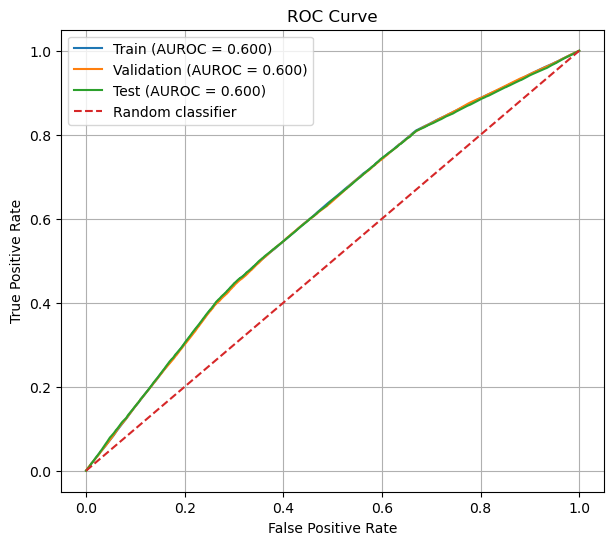

In [390]:
y_test_prob = xgb_hpt.predict_proba(X_test_reduced)[:, 1]
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
auroc_train = roc_auc_score(y_train, y_train_prob)
auroc_val = roc_auc_score(y_val, y_val_prob)
auroc_test = roc_auc_score(y_test, y_test_prob)

# Plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr_train, tpr_train, label=f"Train (AUROC = {auroc_train:.3f})")
plt.plot(fpr_val, tpr_val, label=f"Validation (AUROC = {auroc_val:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test (AUROC = {auroc_test:.3f})")
plt.plot([0, 1],[0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
explainer = shap.TreeExplainer(xgb_hpt)
shap_values = explainer.shap_values(X_val_reduced)
feature_names = reduced_preprocessor.get_feature_names_out()

In [42]:
feature_names

array(['ordinal__Education_Level', 'ordinal__Smoking_Status',
       'ordinal__Alcohol_Consumption', 'ordinal__Dietary_Habits',
       'ordinal__Physical_Activity_Level', 'ordinal__Number_of_Children',
       'numeric__Age', 'numeric__Income', 'numeric__Marital_Status'],
      dtype=object)

### SHAP Plot

In [39]:
sys.path.append("../")
from src.interpretation import create_shap_plot, create_ale_plot, create_pdp_plot

In [43]:
X_val_reduced_df = pd.DataFrame(X_val_reduced, columns=feature_names, index=y_val.index)

In [44]:
feature_names = X_val_reduced_df.columns.tolist()

In [46]:
create_shap_plot(model=xgb_hpt, X=X_val_reduced, feature_names=feature_names, output_path="../figures/shap_summary.png")

### ALE Plot

In [405]:
xgb_hpt.predict_proba(X_val_reduced_df)[:, 1]

array([0.33567214, 0.30763835, 0.23590107, ..., 0.23331709, 0.36554095,
       0.23079008], shape=(82760,), dtype=float32)

In [407]:
class ProbabilityModel:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        return self.model.predict_proba(X)[:, 1]

prob_model = ProbabilityModel(xgb_hpt)

PyALE._ALE_generic:INFO: Continuous feature detected.


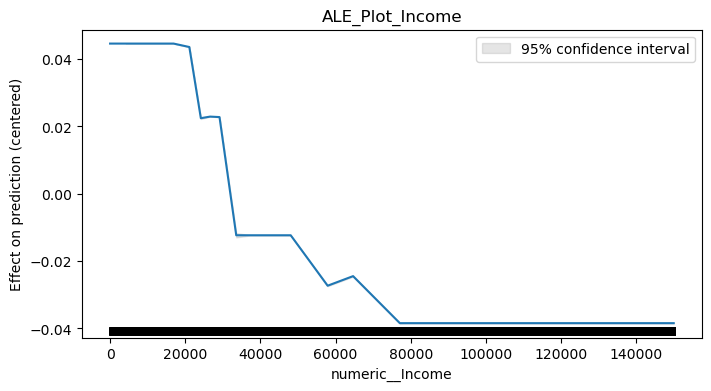

In [408]:
ale(X = X_val_reduced_df, model=prob_model, feature=["numeric__Income"], grid_size=20, include_CI=True)
plt.title("ALE_Plot_Income")
plt.show()

In [ ]:
create_ale_plot(model=xgb_hpt, X=X_val_reduced_df, feature="numeric__Income", output_path="../figures/ale_income.png")

PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Discrete feature detected.


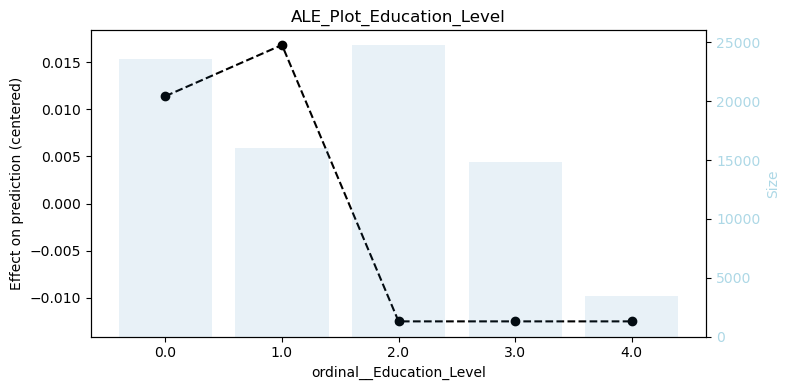

In [ ]:
ale(X = X_val_reduced_df, model=prob_model, feature=["ordinal__Education_Level"], grid_size=20, include_CI=True)
plt.title("ALE_Plot_Education_Level")
plt.show()

In [52]:
create_ale_plot(model=xgb_hpt, X=X_val_reduced_df, feature="ordinal__Education_Level", output_path="../figures/ale_education_level.png")

PyALE._ALE_generic:INFO: Discrete feature detected.


PyALE._ALE_generic:INFO: Discrete feature detected.


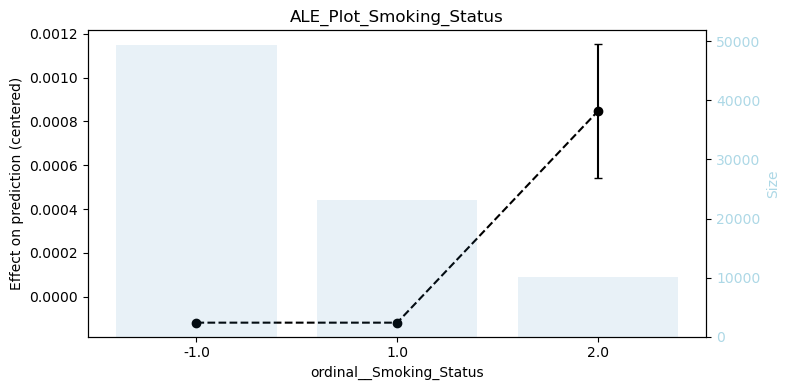

In [410]:
ale(X = X_val_reduced_df, model=prob_model, feature=["ordinal__Smoking_Status"], grid_size=20, include_CI=True)
plt.title("ALE_Plot_Smoking_Status")
plt.show()

In [53]:
create_ale_plot(model=xgb_hpt, X=X_val_reduced_df, feature="ordinal__Smoking_Status", output_path="../figures/ale_smoking_status.png")

PyALE._ALE_generic:INFO: Discrete feature detected.


PyALE._ALE_generic:INFO: Discrete feature detected.


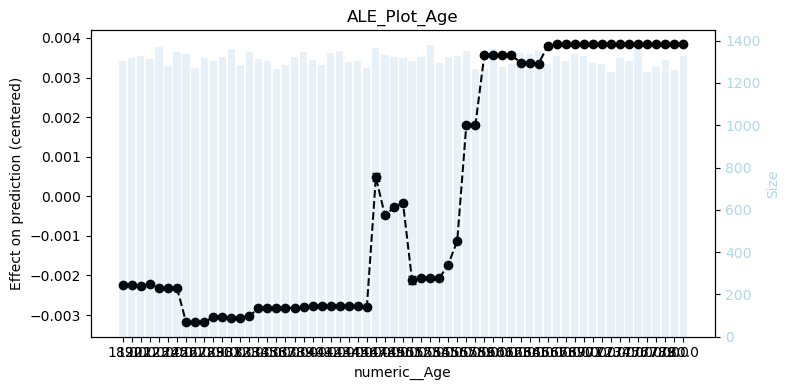

In [411]:
ale(X = X_val_reduced_df, model=prob_model, feature=["numeric__Age"], grid_size=20, include_CI=True)
plt.title("ALE_Plot_Age")
plt.show()

In [54]:
create_ale_plot(model=xgb_hpt, X=X_val_reduced_df, feature="numeric__Age", output_path="../figures/ale_Age.png")

PyALE._ALE_generic:INFO: Discrete feature detected.


### PDP Plot

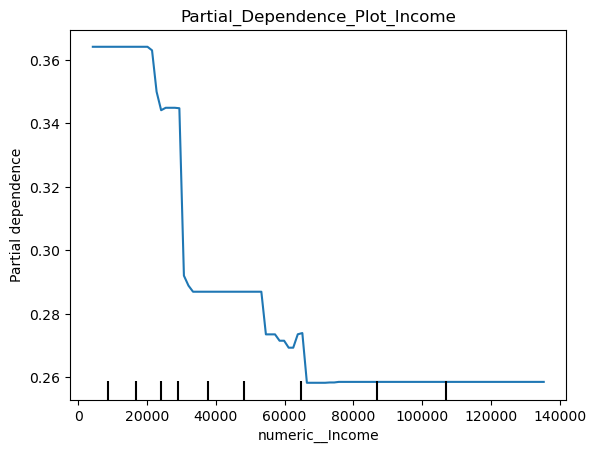

In [ ]:
PartialDependenceDisplay.from_estimator(xgb_hpt, X_val_reduced_df, features=["numeric__Income"], kind="average")
plt.title("Partial_Dependence_Plot_Income")
plt.show()

In [56]:
create_pdp_plot(model=xgb_hpt, X=X_val_reduced_df, feature="numeric__Income", output_path="../figures/pdp_Income.png")

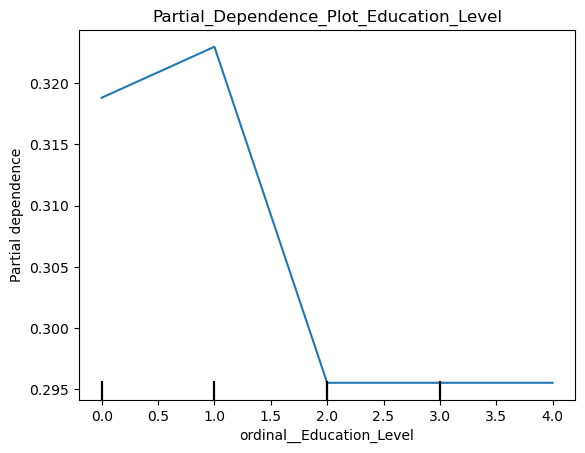

In [413]:
PartialDependenceDisplay.from_estimator(xgb_hpt, X_val_reduced_df, features=["ordinal__Education_Level"], kind="average")
plt.title("Partial_Dependence_Plot_Education_Level")
plt.show()

In [57]:
create_pdp_plot(model=xgb_hpt, X=X_val_reduced_df, feature="ordinal__Education_Level", output_path="../figures/pdp_education_level.png")

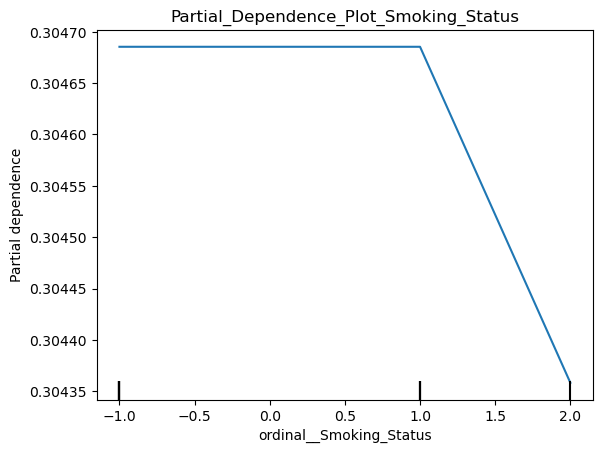

In [414]:
PartialDependenceDisplay.from_estimator(xgb_hpt, X_val_reduced_df, features=["ordinal__Smoking_Status"], kind="average")
plt.title("Partial_Dependence_Plot_Smoking_Status")
plt.show()

In [ ]:
create_pdp_plot(model=xgb_hpt, X=X_val_reduced_df, feature="ordinal__Smoking_Status", output_path="../figures/pdp_smoking_status.png")

In [ ]:
create_pdp_plot(model=xgb_hpt, X=X_val_reduced_df, feature="numeric__Age", output_path="../figures/pdp_Age.png")

## Save Model

In [32]:
import joblib

In [33]:
os.makedirs("../models", exist_ok=True)
joblib.dump(xgb_hpt,"../models/mental_health_xgboost.pkl")

['../models/mental_health_xgboost.pkl']

In [34]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")

['../models/preprocessor.pkl']